In [1]:
from collections import defaultdict
from functools import partial
from multiprocessing import Pool
from pathlib import Path
from pickle import dump, load
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import polars.selectors as cs
import seaborn as sns
from scipy.stats import pearsonr, spearmanrho
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import (
    LogisticRegression,
    LogisticRegressionCV,
)
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedGroupKFold,
    cross_val_predict,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.utils import resample


In [2]:
data_dir = Path("/orcd/data/manoli/001/rcalef/data/vep_comparisons/variants")
variants_path = data_dir / "collated_variants.annotated.tsv.gz"

esmc_scores_path = Path(
    "/orcd/data/manoli/001/rcalef/projects/vep_comparisons/scoring/collated_variants.esmc_300m.tsv.gz"
)

# Evo2 scores present as sharded parquet files in different directories
# for different variant datasets.
evo_dir = Path("/orcd/data/manoli/001/iychan25/evo2-clinvar/results/scores_export/")
evo_score_globs = {
    "finucane_v50": "scores_chunk*",
    "multisusie": "scores_chunk*",
    "eqtl": "scores_chunk*",
    "clinvar": "scores_relabeled.parquet",
}

dataset_labels = {
    # "ukbb": ["high_pip"],
    # "multisusie": ["high_pip"],
    "gwas": ["high_pip"],
    "eqtl": ["high_pip"],
    "clinvar": ["Pathogenic", "Likely_pathogenic"],
}

dataset_names: dict[str, str] = {"gwas": "GWAS", "eqtl": "eQTL", "clinvar": "ClinVar"}

annot_names = {
    "gnocchi_z": "Gnocchi",
    "phylop": "PhyloP",
    # "roulette_mr": "Roulette MR",
    "log_roulette_mr": "log(Roulette MR)",
    "gnomadg_af_log": "log(MAF)",
}

model_names = {
    "evo_score": "Evo2",
    "esmc_score": "ESM-C",
}

## Load all data

Load and merge the following:
- Variants w/ annotations (PhyloP, Gnocchi, Roulette)
    - Create merged "GWAS" group that combines UKBB/Finucane and MultiSuSiE
- Model scores for variant positions
    - ESM-C: protein-coding missense variants only
    - Evo2 (partial): p(ref), p(alt), log-likelihood ratio. Both averaged over forward and reverse direction
    - (TODO) RiNALMo

In [10]:
# Load variants w/ annotations
df = (
    pl.read_csv(
        variants_path,
        separator="\t",
        null_values="-",
        schema_overrides={
            "multisusie_pip": pl.Float64,
            "eqtl_pip": pl.Float64,
        },
    )
    .with_columns(
        gnomadg_af_log=(
            pl.when(pl.col("gnomadg_af") == 0)
            .then(None)
            .otherwise(pl.col("gnomadg_af").log10())
        ),
        log_roulette_mr=pl.col("roulette_mr").log10(),
        gwas_pip=pl.max_horizontal(pl.col("ukbb_pip", "multisusie_pip")),
    )
    .with_columns(
        gwas_label=(
            pl.when(pl.col("gwas_pip") >= 0.5)
            .then(pl.lit("high_pip"))
            .otherwise(pl.lit("low_pip"))
        )
    )
)

print(df.shape)
df.head()

(340507, 42)


variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log,log_roulette_mr,gwas_pip,gwas_label
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64,f64,f64,str
"""chr1:834583:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",834582,834583,204,null,null,null,0.1158,0.3403,0.004209,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.612,null,1.273,null,"""low""",-0.936291,0.104828,0.004209,"""low_pip"""
"""chr1:835506:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",835505,835506,113,null,null,null,0.1093,0.3085,0.004478,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-2.742,null,2.12,null,"""low""",-0.96138,0.326336,0.004478,"""low_pip"""
"""chr1:841852:C:T""","""ENSG00000228794""","""chr1""","""C""","""T""","""ENST00000415295""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""SAS""",841851,841852,726,null,null,0.0843,0.06921,0.1493,0.003612,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.459,null,0.094,null,"""low""",-1.159831,-1.026872,0.003612,"""low_pip"""
"""chr1:856473:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""gnomADe_FIN""",856472,856473,2884,null,null,0.07955,0.07915,0.1923,0.002221,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.166,1.535938,0.105,null,"""low""",-1.101549,-0.978811,0.002221,"""low_pip"""
"""chr1:858952:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""EAS""",858951,858952,5363,null,null,0.02083,0.09489,0.1607,0.002458,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-1.531,null,0.916,null,"""low""",-1.02278,-0.038105,0.002458,"""low_pip"""


In [11]:
# Load ESM-C scores for protein-coding missense variants
esmc_scores = (
    pl.read_csv(
        esmc_scores_path,
        separator="\t",
    )
    # Original scores are log(ref) - log(alt), so negate
    # so we have "pathogenicity" scores instead of
    # "tolerability" scores.
    .with_columns(score=-pl.col("score"))
    .rename({"score": "esmc_score"})
    .select("variant", "esmc_score")
)
print(esmc_scores.shape)
esmc_scores.head()

(48491, 2)


variant,esmc_score
str,f64
"""chr1:930248:G:A""",-1.686048
"""chr1:930312:C:G""",-0.110479
"""chr1:943896:A:G""",-1.41601
"""chr1:946538:G:A""",1.404949
"""chr1:971389:C:A""",-0.172407


In [12]:
def load_one_evo(path: Path, glob: str) -> pl.DataFrame:
    evo_scores = (
        pl.concat([pl.read_parquet(path) for path in sorted(path.glob(glob))])
        .with_columns(chrom=pl.col("chrom").cast(pl.String))
        .with_columns(
            chrom=pl.when(pl.col("chrom").str.contains("chr"))
            .then(pl.col("chrom"))
            .otherwise(pl.format("chr{}", "chrom")),
            evo_ref_prob=pl.mean_horizontal(
                pl.col("score_ref_fwd").exp(), pl.col("score_ref_rev").exp()
            ),
            evo_alt_prob=pl.mean_horizontal(
                pl.col("score_alt_fwd").exp(), pl.col("score_alt_rev").exp()
            ),
        )
        .with_columns(
            variant=pl.format("{}:{}:{}:{}", "chrom", "pos", "ref", "alt"),
            evo_score=pl.col("evo_ref_prob").log() - pl.col("evo_alt_prob").log(),
        )
        .select(
            "variant",
            "evo_ref_prob",
            "evo_alt_prob",
            "evo_score",
        )
    )
    return evo_scores


all_evo_scores = pl.concat(
    [load_one_evo(evo_dir / name, glob) for (name, glob) in evo_score_globs.items()],
    how="diagonal",
).unique("variant")
all_evo_scores.shape

(469215, 4)

In [13]:
(
    all_evo_scores.filter(
        ~pl.col("variant").is_in(df.get_column("variant").to_list())
    ).unique("variant")
)

variant,evo_ref_prob,evo_alt_prob,evo_score
str,f64,f64,f64
"""chr17:30899612:T:A""",0.426274,0.426306,-0.000076
"""chr13:19677953:G:A""",0.324213,0.324343,-0.000402
"""chr13:74168185:T:C""",0.321188,0.32108,0.000336
"""chr12:49038613:G:A""",0.560861,0.55711,0.006711
"""chr15:91908661:G:T""",0.333749,0.333735,0.000041
…,…,…,…
"""chr5:161326441:C:T""",0.305931,0.305879,0.000168
"""chr6:87506858:A:C""",0.339255,0.339277,-0.000065
"""chr5:150129783:G:A""",0.339506,0.339418,0.000261


In [14]:
df = df.join(
    all_evo_scores,
    on="variant",
    how="left",
).join(
    esmc_scores,
    on="variant",
    how="left",
)
print(df.shape)
df.head()

(340927, 46)


variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log,log_roulette_mr,gwas_pip,gwas_label,evo_ref_prob,evo_alt_prob,evo_score,esmc_score
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64,f64,f64,str,f64,f64,f64,f64
"""chr1:834583:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",834582,834583,204,null,null,null,0.1158,0.3403,0.004209,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.612,null,1.273,null,"""low""",-0.936291,0.104828,0.004209,"""low_pip""",0.314054,0.314115,-0.000196,null
"""chr1:835506:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",835505,835506,113,null,null,null,0.1093,0.3085,0.004478,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-2.742,null,2.12,null,"""low""",-0.96138,0.326336,0.004478,"""low_pip""",0.336628,0.33667,-0.000124,null
"""chr1:841852:C:T""","""ENSG00000228794""","""chr1""","""C""","""T""","""ENST00000415295""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""SAS""",841851,841852,726,null,null,0.0843,0.06921,0.1493,0.003612,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.459,null,0.094,null,"""low""",-1.159831,-1.026872,0.003612,"""low_pip""",0.329573,0.329497,0.000231,null
"""chr1:856473:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""gnomADe_FIN""",856472,856473,2884,null,null,0.07955,0.07915,0.1923,0.002221,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.166,1.535938,0.105,null,"""low""",-1.101549,-0.978811,0.002221,"""low_pip""",0.318683,0.318626,0.000177,null
"""chr1:858952:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""EAS""",858951,858952,5363,null,null,0.02083,0.09489,0.1607,0.002458,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-1.531,null,0.916,null,"""low""",-1.02278,-0.038105,0.002458,"""low_pip""",0.306684,0.306683,0.000003,null


## Correlations

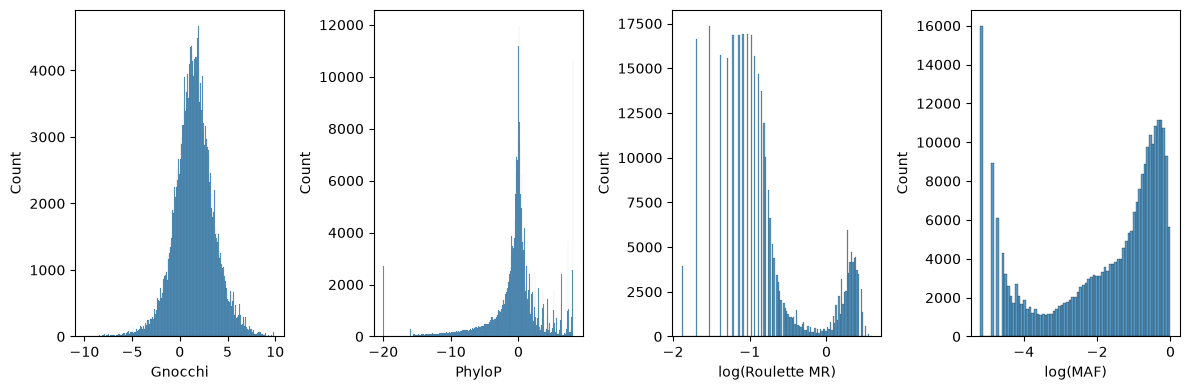

In [ ]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=len(annot_names),
    sharey=False,
    sharex=False,
    figsize=(12, 4),
)
for (annot, name), ax in zip(annot_names.items(), axs):
    sns.histplot(x=df.get_column(annot).drop_nulls(), ax=ax)
    ax.set_xlabel(name)
plt.tight_layout()

In [137]:
hist_color = "#3C6E71"
fit_color = "#D1495B"


def corr_model_vs_annotations(
    data: pl.DataFrame,
    model_col: str,
    annotations: dict[str, str] = annot_names,
    model_name: str | None = None,
    clip: bool = True,
):
    if model_name is None:
        model_name = model_col

    fig, axs = plt.subplots(
        nrows=1,
        ncols=len(annotations),
        sharex=False,
        figsize=(10, 4),
    )
    sns.despine(fig)

    if clip:
        scores = data.get_column(model_col).drop_nulls().to_numpy()
        ymin, ymax = np.quantile(scores, q=(0.001, 0.999))

    for i, ((annot, name), ax) in enumerate(zip(annotations.items(), axs)):
        plot_data = data.filter(
            pl.col(model_col).is_not_null(),
            pl.col(annot).is_not_null(),
        )
        x_vals = plot_data.get_column(annot).to_numpy()
        y_vals = plot_data.get_column(model_col).to_numpy()
        r = pearsonr(x_vals, y_vals)
        rho = spearmanrho(x_vals, y_vals)

        sns.regplot(
            x=plot_data.get_column(annot),
            y=plot_data.get_column(model_col),
            marker=".",
            line_kws={"color": fit_color, "alpha": 0.7},
            ax=ax,
            scatter=False,
        )
        sns.histplot(
            x=plot_data.get_column(annot),
            y=plot_data.get_column(model_col),
            alpha=1,
            color=hist_color,
            ax=ax,
        )
        ax.set_xlabel(name)
        ax.text(
            0.95,
            0.95,
            s=(
                f"r={r.statistic:0.2f}"
                "\n"
                rf"$\rho$={rho.statistic:0.2f}"
            ),
            transform=ax.transAxes,
            ha="right",
            va="top",
        )
        if i == 0:
            ax.set_ylabel(model_name)
        else:
            ax.set_ylabel(None)
        if clip:
            ax.set_ylim(ymin, ymax)

    plt.tight_layout()

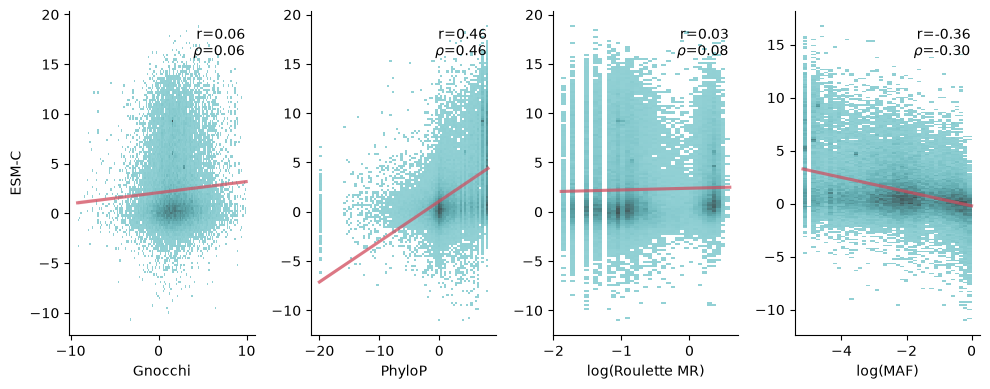

In [138]:
corr_model_vs_annotations(
    data=df,
    model_col="esmc_score",
    model_name="ESM-C",
    clip=False,
)

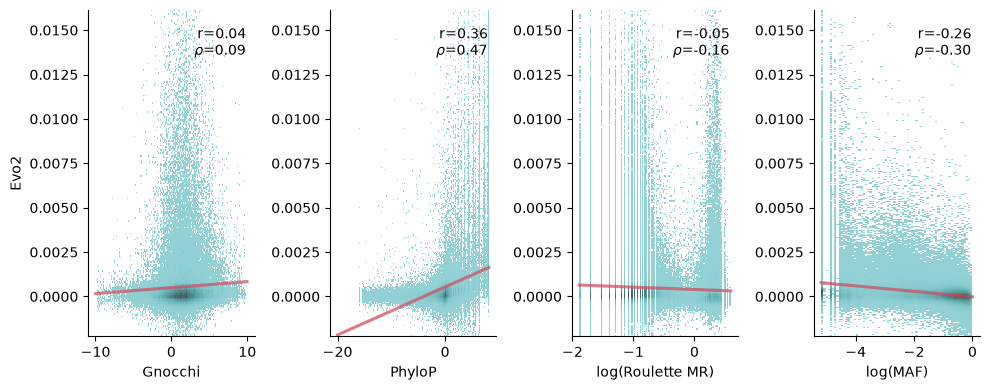

In [140]:
corr_model_vs_annotations(
    # data=df.sample(fraction=0.1),
    data=df,
    model_col="evo_score",
    model_name="Evo2",
    clip=True,
)

340927 -> 191276


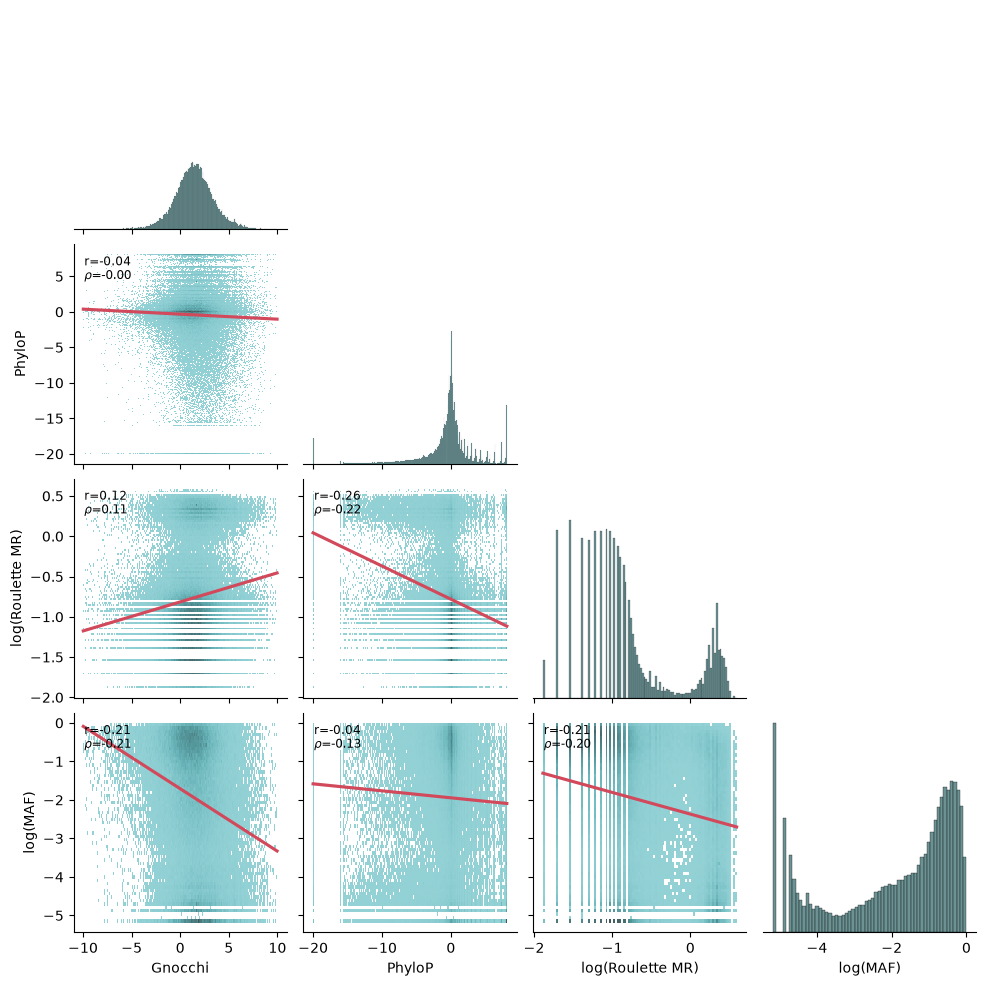

In [136]:
plot_data = df.filter(
    pl.all_horizontal(pl.col(*annot_names.keys()).is_not_null())
).select(annot_names.keys())
print(f"{len(df)} -> {len(plot_data)}")

g = sns.pairplot(
    plot_data.to_pandas(),
    corner=True,
    markers=".",
    kind="hist",
    diag_kws={"color": hist_color},
    plot_kws={"color": hist_color},
)
g.map_lower(sns.regplot, scatter=False, color=fit_color)

for i, row in enumerate(g.axes):
    for j, ax in enumerate(row):
        if ax is None:
            continue

        xvar = ax.get_xlabel()
        yvar = ax.get_ylabel()
        if xvar == "" or yvar == "":
            continue

        xvals = plot_data.get_column(xvar).to_numpy()
        yvals = plot_data.get_column(yvar).to_numpy()

        r = pearsonr(xvals, yvals)
        rho = spearmanrho(xvals, yvals)
        ax.text(
            0.05,
            0.95,
            s=(
                f"r={r.statistic:0.2f}"
                "\n"
                rf"$\rho$={rho.statistic:0.2f}"
            ),
            transform=ax.transAxes,
            ha="left",
            va="top",
            size="small",
        )

        if i == len(annot_names) - 1:
            ax.set_xlabel(annot_names[xvar])
        if j == 0:
            ax.set_ylabel(annot_names[yvar])

last = g.axes[-1][-1]
last.set_xlabel(annot_names[last.get_xlabel()])
g.tight_layout()


## Univariate dataset performance

In [15]:
df.head()

variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log,log_roulette_mr,gwas_pip,gwas_label,evo_ref_prob,evo_alt_prob,evo_score,esmc_score
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64,f64,f64,str,f64,f64,f64,f64
"""chr1:834583:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",834582,834583,204,null,null,null,0.1158,0.3403,0.004209,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.612,null,1.273,null,"""low""",-0.936291,0.104828,0.004209,"""low_pip""",0.314054,0.314115,-0.000196,null
"""chr1:835506:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",835505,835506,113,null,null,null,0.1093,0.3085,0.004478,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-2.742,null,2.12,null,"""low""",-0.96138,0.326336,0.004478,"""low_pip""",0.336628,0.33667,-0.000124,null
"""chr1:841852:C:T""","""ENSG00000228794""","""chr1""","""C""","""T""","""ENST00000415295""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""SAS""",841851,841852,726,null,null,0.0843,0.06921,0.1493,0.003612,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.459,null,0.094,null,"""low""",-1.159831,-1.026872,0.003612,"""low_pip""",0.329573,0.329497,0.000231,null
"""chr1:856473:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""gnomADe_FIN""",856472,856473,2884,null,null,0.07955,0.07915,0.1923,0.002221,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.166,1.535938,0.105,null,"""low""",-1.101549,-0.978811,0.002221,"""low_pip""",0.318683,0.318626,0.000177,null
"""chr1:858952:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""EAS""",858951,858952,5363,null,null,0.02083,0.09489,0.1607,0.002458,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-1.531,null,0.916,null,"""low""",-1.02278,-0.038105,0.002458,"""low_pip""",0.306684,0.306683,0.000003,null


In [62]:
def raw_score_comparison(
    data: pl.DataFrame,
    dataset_labels: dict[str, list[str]] = dataset_labels,
    scores: list[str] = list(annot_names.keys()) + list(model_names.keys()),
    title: str | None = None,
) -> pl.DataFrame:

    want_data = data.with_columns(
        **{
            f"{dataset}": pl.col(f"{dataset}_label").is_in(pos_labels).cast(pl.UInt8)
            for dataset, pos_labels in dataset_labels.items()
        }
    ).filter(pl.all_horizontal(pl.col(*scores).is_not_null()))

    metrics = []
    for dataset in dataset_labels:
        ds_data = want_data.filter(pl.col(dataset).is_not_null())
        y_true = ds_data.get_column(dataset)
        print(f"{dataset}: {y_true.sum()} / {len(y_true)}")

        for score in scores:
            y_pred = ds_data.get_column(score)
            metrics.append(
                {
                    "dataset": dataset,
                    "score": score,
                    "auroc": roc_auc_score(y_true=y_true, y_score=y_pred),
                    "auprc": average_precision_score(y_true=y_true, y_score=y_pred),
                }
            )

    score_rename = {}
    score_rename.update(annot_names)
    score_rename.update(model_names)
    metrics = (
        pl.DataFrame(metrics)
        .with_columns(
            score=pl.col("score").replace(score_rename),
            dataset=pl.col("dataset").replace(dataset_names),
        )
        .unpivot(
            on=["auroc", "auprc"],
            index=["dataset", "score"],
            variable_name="metric",
            value_name="value",
        )
    )

    fg = sns.FacetGrid(data=metrics, col="metric", aspect=1.5, height=5, sharey=False)
    fg.map_dataframe(sns.barplot, x="dataset", hue="score", y="value", palette="muted")
    fg.set_titles("")
    fg.add_legend()

    auroc_ax = fg.axes[0][0]
    auroc_ax.set_ylim(0.4)
    auroc_ax.axhline(y=0.5, linestyle="--", alpha=0.6, color="black")
    auroc_ax.set_ylabel("AUROC")
    fg.axes[0][1].set_ylabel("AUPRC")

    if title is not None:
        plt.suptitle(title)
    plt.tight_layout()

    # plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
    # plt.axhline(y=0.5, linestyle="--", alpha=0.6, color="black")
    # plt.ylim(0.4)
    # plt.show()

    # sns.barplot(
    #     x="dataset",
    #     hue="score",
    #     y="auprc",
    #     data=metrics,
    # )

    return metrics

gwas: 473 / 27773
eqtl: 451 / 3539
clinvar: 1958 / 18380


dataset,score,metric,value
str,str,str,f64
"""GWAS""","""Gnocchi""","""auroc""",0.557746
"""GWAS""","""PhyloP""","""auroc""",0.648413
"""GWAS""","""log(Roulette MR)""","""auroc""",0.549392
"""GWAS""","""log(MAF)""","""auroc""",0.399054
"""GWAS""","""Evo2""","""auroc""",0.62213
…,…,…,…
"""ClinVar""","""PhyloP""","""auprc""",0.299696
"""ClinVar""","""log(Roulette MR)""","""auprc""",0.147126
"""ClinVar""","""log(MAF)""","""auprc""",0.617481


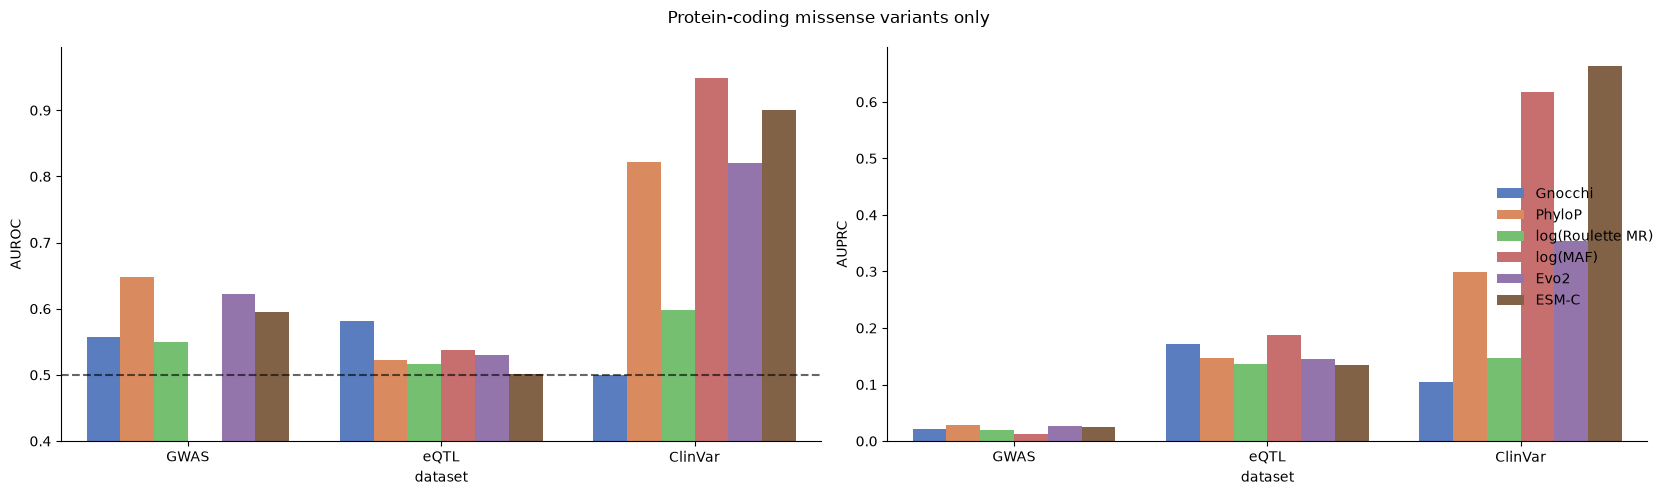

In [63]:
raw_score_comparison(
    df.with_columns(gnomadg_af_log=-pl.col("gnomadg_af_log")),
    title="Protein-coding missense variants only",
)


gwas: 1153 / 180804
eqtl: 6289 / 49243
clinvar: 4180 / 71537


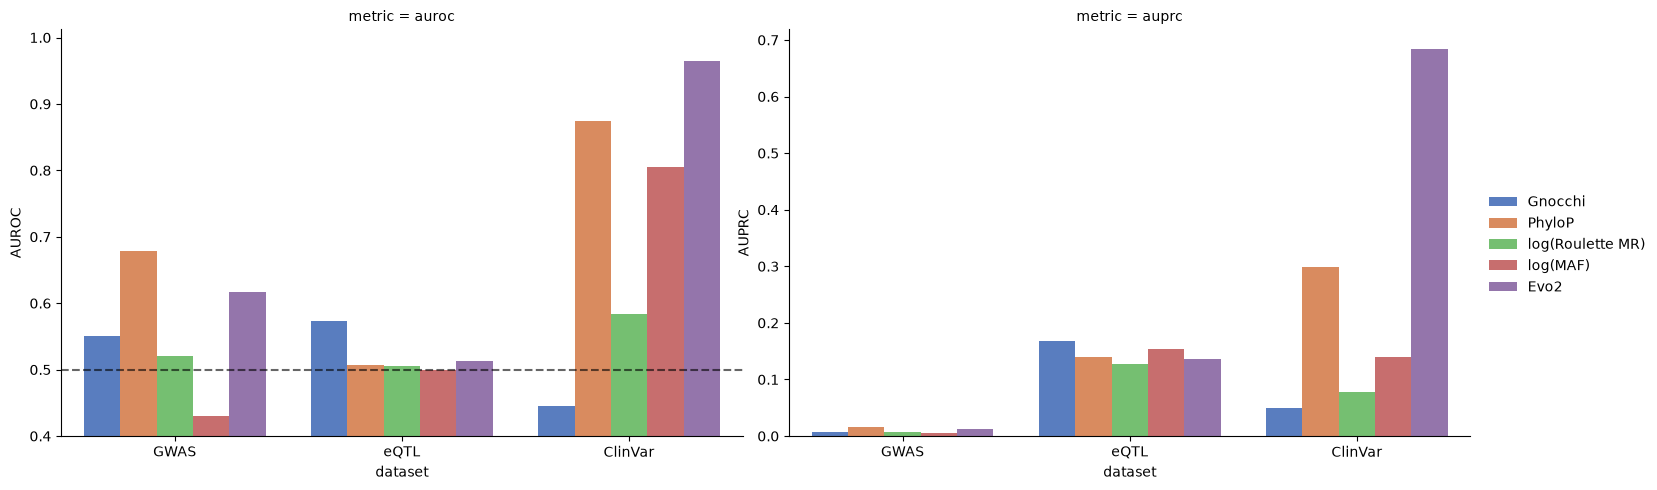

In [58]:
gw_metrics = raw_score_comparison(
    df.with_columns(gnomadg_af_log=-pl.col("gnomadg_af_log")),
    scores=list(annot_names.keys()) + ["evo_score"],
)

In [ ]:
def raw_score_comparison(
    data: pl.DataFrame,
    dataset: str = "ukbb",
    pos_labels: list[str] = ["high_pip"],
    neg_labels: list[str] = ["low_pip"],
    all_non_null: bool = True,
    refilter_pip: bool = False,
    high_pip: float = 0.5,
    low_pip: float = 0.1,
    pos_name: str = "high PIP",
    neg_name: str = "low PIP",
):

    want_data = df.rename({f"{dataset}_{col}": col for col in label_cols}).filter(
        pl.col("label").is_not_null()
    )
    if all_non_null:
        want_data = want_data.filter(
            pl.all_horizontal(pl.col(annotations).is_not_null())
        )

    by_category = pl.concat(
        (
            want_data.with_columns(biotype=pl.lit("mixed")),
            want_data.filter(pl.col("biotype") == "lncRNA"),
            want_data.filter(pl.col("biotype") == "protein_coding"),
        )
    )

    print(f"{dataset}: {len(want_data)} rows")

    if refilter_pip:
        assert high_pip >= 0.5
        assert low_pip <= 0.1
        by_category = by_category.with_columns(
            label=(
                pl.when(pl.col("pip") >= high_pip)
                .then(pl.lit("high_pip"))
                .otherwise(
                    pl.when(pl.col("pip") <= low_pip)
                    .then(pl.lit("low_pip"))
                    .otherwise(None),
                )
            )
        ).filter(pl.col("label").is_not_null())

    long = by_category.unpivot(
        on=annotations,
        index=label_cols + ["biotype"],
        variable_name="annotation",
        value_name="score",
    ).with_columns(
        label=pl.when(pl.col("label").is_in(pos_labels))
        .then(pl.lit(pos_name))
        .otherwise(
            pl.when(pl.col("label").is_in(neg_labels))
            .then(pl.lit(neg_name))
            .otherwise(None),
        )
    )

    all_aucs = {}
    for biotype in ["mixed", "lncRNA", "protein_coding"]:
        for annot in annotations:
            want_rows = long.filter(
                pl.col("annotation") == annot,
                pl.col("score").is_not_null(),
                pl.col("biotype") == biotype,
            )

            auc = roc_auc_score(
                y_true=(want_rows.get_column("label") == pos_name)
                .cast(pl.UInt8)
                .to_numpy(),
                y_score=(want_rows.get_column("score")).to_numpy(),
            )
            num_pos = (want_rows.get_column("label") == pos_name).sum()
            num_neg = (want_rows.get_column("label") == neg_name).sum()

            print(
                f"{dataset}: {biotype} - {annot} ({num_pos} / {num_neg}) -> AUC={auc:0.3f}"
            )
            all_aucs[(biotype, annot)] = auc

    fg = sns.FacetGrid(
        long,
        col="annotation",
        row="biotype",
        sharey=False,
    )
    fg.map_dataframe(sns.boxplot, x="label", y="score")
    for (biotype, annot), ax in fg.axes_dict.items():
        auc = all_aucs[(biotype, annot)]
        ax.set_title(f"biotype={biotype}\nannotation={annot}\nAUC={auc:0.3f}")

    plt.suptitle(f"dataset = {dataset}")
    fg.tight_layout()

    return fg

In [ ]:
check = df.filter(pl.col("clinvar_label").is_not_null()).join(
    all_evo_scores, on="variant", how="inner"
)
check.shape

(153028, 42)

In [ ]:
check.head()

variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log,evo_ref_prob,evo_alt_prob,evo_score
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64,f64,f64,f64
"""chr1:152308696:T:G""","""ENSG00000143631""","""chr1""","""T""","""G""","""ENST00000368799""","""missense_variant""","""K/Q""","""FLG""","""protein_coding""","""gnomADe_AFR""",152308695,152308696,6262,6190,2064,0.01086,0.09409,0.3339,null,null,null,null,null,null,null,null,null,null,null,"""Benign""",1195856,2,-1.033,null,0.013,null,"""low""",1.026457,0.738068,0.738497,-0.000581
"""chr16:2086294:G:A""","""ENSG00000103197""","""chr16""","""G""","""A""","""ENST00000219476""","""synonymous_variant""","""Q""","""TSC2""","""protein_coding""",null,2086293,2086294,4874,4764,1588,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""Likely_benign""",466103,2,1.955,null,0.139,null,"""TFBS""",null,0.365474,0.365304,0.000464
"""chr2:15366610:G:A""","""ENSG00000151779""","""chr2""","""G""","""A""","""ENST00000281513""","""synonymous_variant""","""L""","""NBAS""","""protein_coding""","""gnomADe_REMAINING""",15366609,15366610,3817,3787,1263,0.0002107,0.0001774,0.000563,null,null,null,null,null,null,null,null,null,null,null,"""Likely_benign""",732844,2,2.95,0.101456,0.105,null,"""TFBS""",3.751046,0.340568,0.340482,0.000254
"""chr4:54273663:C:T""","""ENSG00000134853""","""chr4""","""C""","""T""","""ENST00000257290""","""synonymous_variant""","""I""","""PDGFRA""","""protein_coding""","""gnomADe_SAS""",54273662,54273663,1626,1491,497,0.000003,0.000013,0.000046,null,null,null,null,null,null,null,null,null,null,null,"""Likely_benign""",1071725,2,-1.402,2.770941,1.772,null,"""high""",4.881074,0.358314,0.35832,-0.000017
"""chr17:6433979:C:T""","""ENSG00000129221""","""chr17""","""C""","""T""","""ENST00000381129""","""stop_gained""","""W/*""","""AIPL1""","""protein_coding""",null,6433978,6433979,233,216,72,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""Pathogenic""",4200356,3,8.076,2.636748,0.128,null,"""TFBS""",null,0.417506,0.414611,0.006959


<Axes: xlabel='clinvar_label', ylabel='evo_score'>

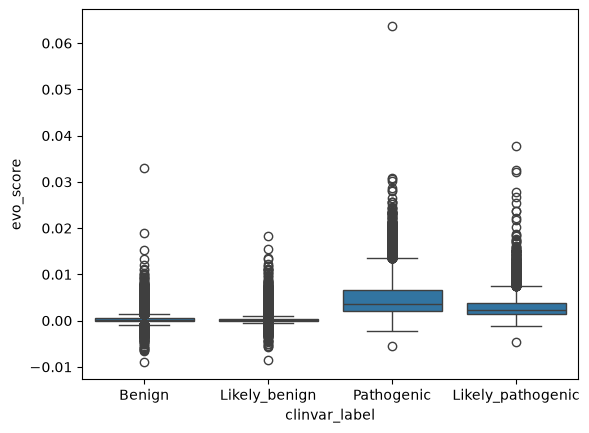

In [ ]:
sns.boxplot(x="clinvar_label", y="evo_score", data=check)

In [ ]:
roc_auc_score(
    y_true=np.where(check.get_column("clinvar_label").str.contains("athogenic"), 1, 0),
    y_score=check.get_column("evo_score"),
)

0.978056531608085

In [ ]:
evo_scores.get_column("variant").is_in(
    df.get_column("variant").to_list()
).value_counts()

variant,count
bool,u32
true,124876
false,36618


In [ ]:
(evo_scores.filter(~pl.col("variant").is_in(df.get_column("variant").to_list())))

chrom,pos,ref,alt,label,fraction,pip,trait,score_ref_fwd,score_alt_fwd,score_ref_rev,score_alt_rev,delta_fwd,delta_rev,delta_avg,variant
i64,i64,str,str,i64,str,f64,str,f64,f64,f64,f64,f64,f64,f64,str
1,923421,"""A""","""G""",0,"""nc""",0.114526,"""eGFRcys""",-1.129439,-1.12964,-1.131499,-1.131692,-0.000201,-0.000193,-0.000197,"""chr1:923421:A:G"""
1,946247,"""G""","""A""",0,"""pc""",0.117058,"""ALP""",-0.991292,-0.991791,-0.996675,-0.996606,-0.000499,0.00007,-0.000215,"""chr1:946247:G:A"""
1,946653,"""G""","""A""",0,"""pc""",0.00278,"""Ca""",-1.010457,-1.010462,-0.993548,-0.993574,-0.000005,-0.000025,-0.000015,"""chr1:946653:G:A"""
1,955679,"""C""","""T""",0,"""pc""",0.252114,"""ALP""",-1.033792,-1.033924,-1.021634,-1.021602,-0.000132,0.000032,-0.00005,"""chr1:955679:C:T"""
1,958082,"""C""","""T""",0,"""pc""",0.001661,"""SBP""",-0.968587,-0.96807,-0.954029,-0.953531,0.000517,0.000498,0.000508,"""chr1:958082:C:T"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
9,138123110,"""A""","""G""",0,"""pc""",0.001319,"""RBC""",-0.973186,-0.972961,-0.974578,-0.974731,0.000225,-0.000153,0.000036,"""chr9:138123110:A:G"""
9,138123517,"""C""","""T""",0,"""pc""",0.003306,"""Morning_Person""",-0.973669,-0.973154,-0.977524,-0.977446,0.000515,0.000077,0.000296,"""chr9:138123517:C:T"""
9,138123971,"""C""","""T""",0,"""pc""",0.001364,"""RBC""",-0.970202,-0.970371,-0.979287,-0.979498,-0.000169,-0.00021,-0.00019,"""chr9:138123971:C:T"""


In [ ]:
(
    df.filter(
        pl.col("ukbb_label").is_not_null(),
    )
    .get_column("variant")
    .is_in(evo_scores.get_column("variant").to_list())
    .value_counts()
)

variant,count
bool,u32
false,1271
true,121999


In [ ]:
(
    df.filter(
        pl.col("ukbb_label").is_not_null(),
        ~pl.col("variant").is_in(evo_scores.get_column("variant").to_list()),
    )
)

variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64
"""chr1:922671:C:T""","""ENSG00000223764""","""chr1""","""C""","""T""","""ENST00000756700""","""splice_donor_variant,non_codin…",null,"""LINC02593""","""lncRNA""","""gnomADg_AMI""",922670,922671,null,null,null,null,0.1755,0.3877,0.044334,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.206,null,0.186,0.186,"""TFBS""",0.755723
"""chr1:1174523:C:T""","""ENSG00000205231""","""chr1""","""C""","""T""","""ENST00000379317""","""non_coding_transcript_exon_var…",null,"""TTLL10-AS1""","""lncRNA""","""AFR""",1174522,1174523,2065,null,null,0.01923,0.09344,0.1936,0.001213,"""low_pip""",null,null,0.079926,"""low_pip""","""ENSG00000205231""",null,"""Testis""","""Brain_Nucleus_accumbens_basal_…",null,null,null,null,-3.36,null,1.47,1.238,"""TFBS""",1.029467
"""chr1:1174573:G:A""","""ENSG00000205231""","""chr1""","""G""","""A""","""ENST00000379317""","""non_coding_transcript_exon_var…",null,"""TTLL10-AS1""","""lncRNA""","""gnomADe_AFR""",1174572,1174573,2015,null,null,0.02778,0.08095,0.5,0.001341,"""low_pip""",null,null,0.026946,"""low_pip""","""ENSG00000205231""",null,"""Brain_Nucleus_accumbens_basal_…","""Brain_Caudate_basal_ganglia,Br…",null,null,null,null,-0.671,null,1.715,1.427,"""TFBS""",1.091783
"""chr1:1174655:T:C""","""ENSG00000205231""","""chr1""","""T""","""C""","""ENST00000379317""","""non_coding_transcript_exon_var…",null,"""TTLL10-AS1""","""lncRNA""","""gnomADg_ASJ""",1174654,1174655,1933,null,null,0.0,0.003595,0.02362,0.001438,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-1.734,null,0.083,0.083,"""TFBS""",2.444301
"""chr1:1317881:C:T""","""ENSG00000240731""","""chr1""","""C""","""T""","""ENST00000444968""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""AMR""",1317880,1317881,86,null,null,0.0,0.000099,0.0014,0.001684,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.942,0.585093,2.526,null,"""TFBS""",4.004979
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr22:46054011:G:A""","""ENSG00000182257""","""chr22""","""G""","""A""","""ENST00000649288""","""non_coding_transcript_exon_var…",null,"""PRR34""","""lncRNA""","""gnomADg_AMI""",46054010,46054011,134,null,null,0.3215,0.3019,0.3551,0.001222,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.051,null,0.301,null,"""TFBS""",0.520137
"""chr22:49286620:A:G""","""ENSG00000300754""","""chr22""","""A""","""G""","""ENST00000773840""","""splice_donor_variant,non_codin…",null,null,"""lncRNA""","""gnomADg_EAS""",49286619,49286620,null,null,null,null,0.1172,0.2038,0.001023,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-1.92,null,0.083,null,"""high""",0.931072
"""chr22:50245867:T:C""","""ENSG00000288871""","""chr22""","""T""","""C""","""ENST00000685176""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""AFR""",50245866,50245867,1258,null,null,0.7432,0.8012,0.9849,0.0237968,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.272,null,0.083,0.073,"""TFBS""",0.096259


In [ ]:
df.get_column("gnomadg_af").is_null().value_counts()

gnomadg_af,count
bool,u32
true,56823
false,283684


In [ ]:
df.filter(pl.col("gnomadg_af").is_null()).head()


variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64
"""chr1:1508989:A:G""","""ENSG00000290916""","""chr1""","""A""","""G""","""ENST00000734699""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""AFR""",1508988,1508989,22,null,null,null,null,0.1029,0.001212,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.805,1.731383,0.105,null,"""low""",null
"""chr1:2228589:G:C""","""ENSG00000157933""","""chr1""","""G""","""C""","""ENST00000378536""","""5_prime_UTR_variant""",null,"""SKI""","""protein_coding""","""AMR""",2228588,2228589,271,null,null,null,null,0.2565,0.049953,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,5.414,null,0.073,0.073,"""TFBS""",null
"""chr1:2228593:G:C""","""ENSG00000157933""","""chr1""","""G""","""C""","""ENST00000378536""","""5_prime_UTR_variant""",null,"""SKI""","""protein_coding""","""AMR""",2228592,2228593,275,null,null,0.0,null,0.2565,0.049992,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,3.859,null,0.073,0.073,"""TFBS""",null
"""chr1:56646100:T:C""","""ENSG00000162409""","""chr1""","""T""","""C""","""ENST00001122725""","""3_prime_UTR_variant""",null,"""PRKAA2""","""protein_coding""","""SAS""",56646099,56646100,540,null,null,null,null,0.1115,0.003554,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.278,-0.186566,0.083,0.083,"""TFBS""",null
"""chr1:56646101:G:A""","""ENSG00000162409""","""chr1""","""G""","""A""","""ENST00001122725""","""3_prime_UTR_variant""",null,"""PRKAA2""","""protein_coding""","""SAS""",56646100,56646101,541,null,null,null,null,0.1115,0.001384,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.1,-0.186566,0.117,0.117,"""TFBS""",null


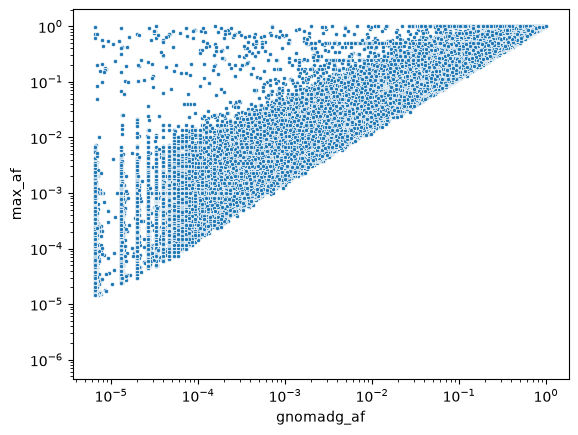

In [ ]:
sns.scatterplot(
    x="gnomadg_af",
    y="max_af",
    data=df,
    marker=".",
)
plt.xscale("log")
plt.yscale("log")

In [ ]:
(
    df.filter(
        pl.col("gnomadg_af") < 1e-3,
        pl.col("max_af") > 1e-1,
    ).head()
)


variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64
"""chr1:1229085:C:T""","""ENSG00000078808""","""chr1""","""C""","""T""","""ENST00000900955""","""5_prime_UTR_variant""",null,"""SDF4""","""protein_coding""","""AFR""",1229084,1229085,2843,null,null,null,0.000008,0.2126,0.001944,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-1.058,null,0.151,null,"""low""",5.103915
"""chr1:1508987:G:T""","""ENSG00000290916""","""chr1""","""G""","""T""","""ENST00000734699""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""AFR""",1508986,1508987,20,null,null,null,0.00002,0.1021,0.001252,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.871,1.731383,0.02,null,"""low""",4.694004
"""chr1:1508988:C:T""","""ENSG00000290916""","""chr1""","""C""","""T""","""ENST00000734699""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""AFR""",1508987,1508988,21,null,null,null,0.000014,0.1029,0.001212,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.04,1.731383,0.174,null,"""low""",4.842543
"""chr1:28247131:A:G""","""ENSG00000270605""","""chr1""","""A""","""G""","""ENST00000823821""","""non_coding_transcript_exon_var…",null,"""ATP5IF1-AS1""","""lncRNA""","""AFR""",28247130,28247131,80,null,null,0.0,0.0001985,0.6256,0.008735,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.129,null,0.073,null,"""low""",3.702239
"""chr1:48055191:A:G""","""ENSG00000226133""","""chr1""","""A""","""G""","""ENST00000635446""","""non_coding_transcript_exon_var…",null,"""LINC02794""","""lncRNA""","""EUR""",48055190,48055191,535,null,null,0.0,0.0003345,0.2823,0.004691,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.283,-0.596263,0.062,null,"""TFBS""",3.475604


In [ ]:
df.head()

variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str
"""chr1:834583:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",834582,834583,204,null,null,null,0.1158,0.3403,0.004209,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.612,null,1.273,null,"""low"""
"""chr1:835506:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",835505,835506,113,null,null,null,0.1093,0.3085,0.004478,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-2.742,null,2.12,null,"""low"""
"""chr1:841852:C:T""","""ENSG00000228794""","""chr1""","""C""","""T""","""ENST00000415295""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""SAS""",841851,841852,726,null,null,0.0843,0.06921,0.1493,0.003612,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.459,null,0.094,null,"""low"""
"""chr1:856473:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""gnomADe_FIN""",856472,856473,2884,null,null,0.07955,0.07915,0.1923,0.002221,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.166,1.535938,0.105,null,"""low"""
"""chr1:858952:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""EAS""",858951,858952,5363,null,null,0.02083,0.09489,0.1607,0.002458,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-1.531,null,0.916,null,"""low"""


## Raw annotation comparisons

In [ ]:
annotations = ["roulette_mr", "gnocchi_z", "phylop", "gnomadg_af_log"]

label_cols = [
    "pip",
    "label",
]


def raw_score_comparison(
    data: pl.DataFrame,
    dataset: str = "ukbb",
    pos_labels: list[str] = ["high_pip"],
    neg_labels: list[str] = ["low_pip"],
    all_non_null: bool = True,
    refilter_pip: bool = False,
    high_pip: float = 0.5,
    low_pip: float = 0.1,
    pos_name: str = "high PIP",
    neg_name: str = "low PIP",
):

    want_data = df.rename({f"{dataset}_{col}": col for col in label_cols}).filter(
        pl.col("label").is_not_null()
    )
    if all_non_null:
        want_data = want_data.filter(
            pl.all_horizontal(pl.col(annotations).is_not_null())
        )

    by_category = pl.concat(
        (
            want_data.with_columns(biotype=pl.lit("mixed")),
            want_data.filter(pl.col("biotype") == "lncRNA"),
            want_data.filter(pl.col("biotype") == "protein_coding"),
        )
    )

    print(f"{dataset}: {len(want_data)} rows")

    if refilter_pip:
        assert high_pip >= 0.5
        assert low_pip <= 0.1
        by_category = by_category.with_columns(
            label=(
                pl.when(pl.col("pip") >= high_pip)
                .then(pl.lit("high_pip"))
                .otherwise(
                    pl.when(pl.col("pip") <= low_pip)
                    .then(pl.lit("low_pip"))
                    .otherwise(None),
                )
            )
        ).filter(pl.col("label").is_not_null())

    long = by_category.unpivot(
        on=annotations,
        index=label_cols + ["biotype"],
        variable_name="annotation",
        value_name="score",
    ).with_columns(
        label=pl.when(pl.col("label").is_in(pos_labels))
        .then(pl.lit(pos_name))
        .otherwise(
            pl.when(pl.col("label").is_in(neg_labels))
            .then(pl.lit(neg_name))
            .otherwise(None),
        )
    )

    all_aucs = {}
    for biotype in ["mixed", "lncRNA", "protein_coding"]:
        for annot in annotations:
            want_rows = long.filter(
                pl.col("annotation") == annot,
                pl.col("score").is_not_null(),
                pl.col("biotype") == biotype,
            )

            auc = roc_auc_score(
                y_true=(want_rows.get_column("label") == pos_name)
                .cast(pl.UInt8)
                .to_numpy(),
                y_score=(want_rows.get_column("score")).to_numpy(),
            )
            num_pos = (want_rows.get_column("label") == pos_name).sum()
            num_neg = (want_rows.get_column("label") == neg_name).sum()

            print(
                f"{dataset}: {biotype} - {annot} ({num_pos} / {num_neg}) -> AUC={auc:0.3f}"
            )
            all_aucs[(biotype, annot)] = auc

    fg = sns.FacetGrid(
        long,
        col="annotation",
        row="biotype",
        sharey=False,
    )
    fg.map_dataframe(sns.boxplot, x="label", y="score")
    for (biotype, annot), ax in fg.axes_dict.items():
        auc = all_aucs[(biotype, annot)]
        ax.set_title(f"biotype={biotype}\nannotation={annot}\nAUC={auc:0.3f}")

    plt.suptitle(f"dataset = {dataset}")
    fg.tight_layout()

    return fg

In [ ]:
raw_score_comparison(df, dataset="ukbb", high_pip=0.5, low_pip=0.1)

ukbb: 81784 rows
ukbb: mixed - roulette_mr (1046 / 80738) -> AUC=0.555
ukbb: mixed - gnocchi_z (1046 / 80738) -> AUC=0.596
ukbb: mixed - phylop (1046 / 80738) -> AUC=0.711


ValueError: Input contains infinity or a value too large for dtype('float64').

multisusie: 4975 rows
multisusie: mixed - roulette_mr (182 / 4793) -> AUC=0.580
multisusie: mixed - gnocchi_z (182 / 4793) -> AUC=0.572
multisusie: mixed - phylop (182 / 4793) -> AUC=0.631
multisusie: lncRNA - roulette_mr (38 / 1698) -> AUC=0.631
multisusie: lncRNA - gnocchi_z (38 / 1698) -> AUC=0.547
multisusie: lncRNA - phylop (38 / 1698) -> AUC=0.516
multisusie: protein_coding - roulette_mr (144 / 3095) -> AUC=0.565
multisusie: protein_coding - gnocchi_z (144 / 3095) -> AUC=0.565
multisusie: protein_coding - phylop (144 / 3095) -> AUC=0.655


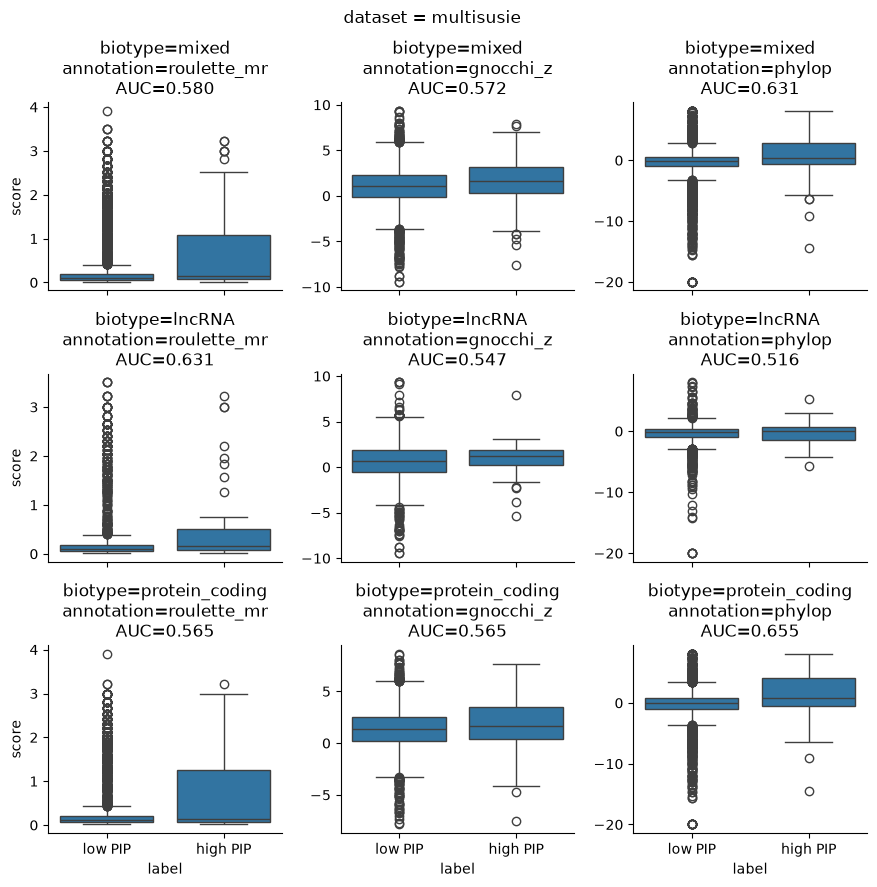

In [ ]:
raw_score_comparison(df, dataset="multisusie", high_pip=0.5, low_pip=0.1)

eqtl: 50236 rows
eqtl: mixed - roulette_mr (6527 / 43709) -> AUC=0.505
eqtl: mixed - gnocchi_z (6527 / 43709) -> AUC=0.573
eqtl: mixed - phylop (6527 / 43709) -> AUC=0.507
eqtl: lncRNA - roulette_mr (2644 / 12891) -> AUC=0.501
eqtl: lncRNA - gnocchi_z (2644 / 12891) -> AUC=0.582
eqtl: lncRNA - phylop (2644 / 12891) -> AUC=0.507
eqtl: protein_coding - roulette_mr (3883 / 30818) -> AUC=0.508
eqtl: protein_coding - gnocchi_z (3883 / 30818) -> AUC=0.580
eqtl: protein_coding - phylop (3883 / 30818) -> AUC=0.517


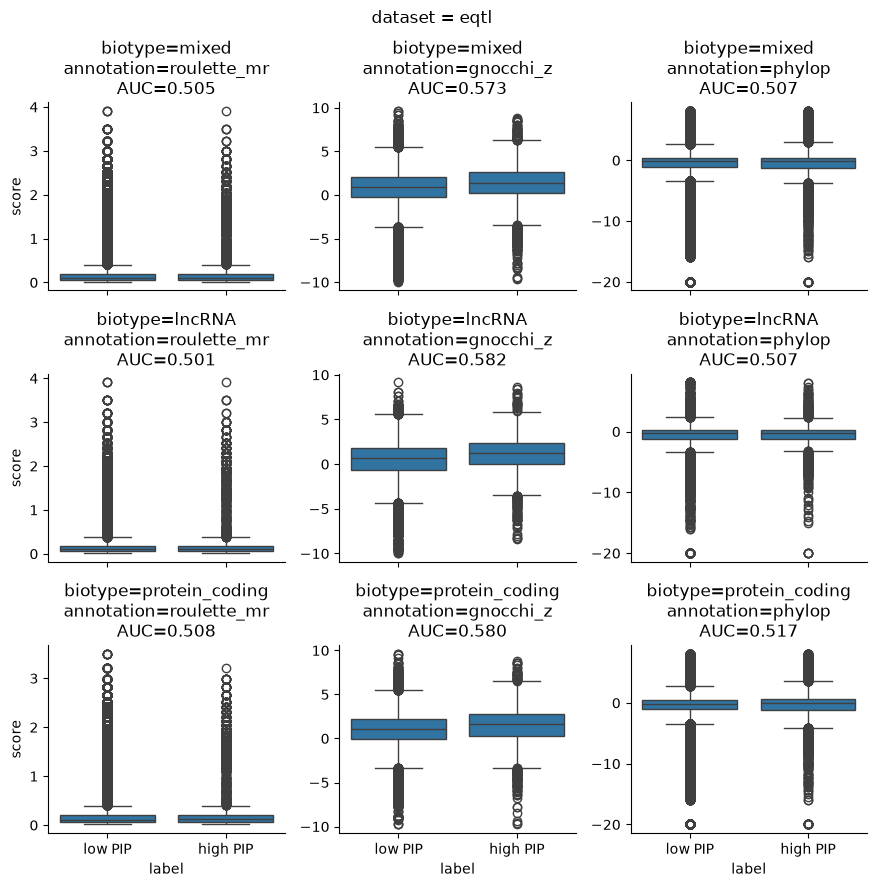

In [ ]:
raw_score_comparison(df, dataset="eqtl", high_pip=0.5, low_pip=0.1)

clinvar: 122421 rows
clinvar: mixed - roulette_mr (21934 / 100487) -> AUC=0.434
clinvar: mixed - gnocchi_z (21934 / 100487) -> AUC=0.471
clinvar: mixed - phylop (21934 / 100487) -> AUC=0.906
clinvar: lncRNA - roulette_mr (6 / 935) -> AUC=0.549
clinvar: lncRNA - gnocchi_z (6 / 935) -> AUC=0.574
clinvar: lncRNA - phylop (6 / 935) -> AUC=0.889
clinvar: protein_coding - roulette_mr (21928 / 99552) -> AUC=0.434
clinvar: protein_coding - gnocchi_z (21928 / 99552) -> AUC=0.471
clinvar: protein_coding - phylop (21928 / 99552) -> AUC=0.906


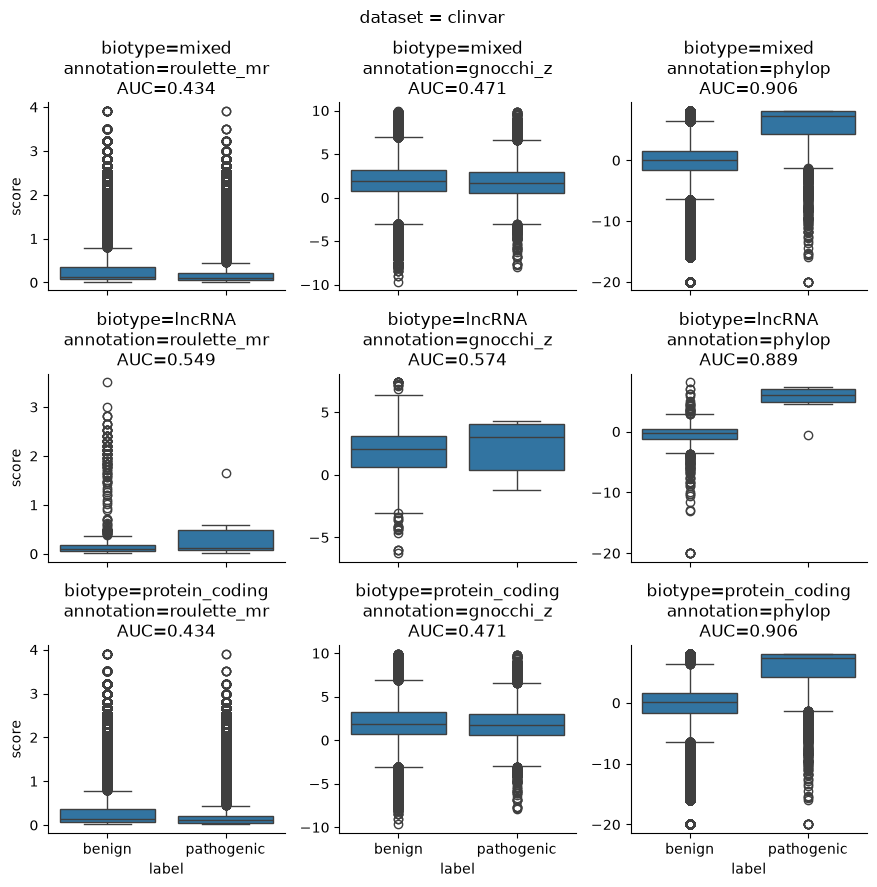

In [ ]:
raw_score_comparison(
    df,
    dataset="clinvar",
    pos_labels=["Pathogenic", "Likely_pathogenic"],
    neg_labels=["Benign", "Likely_benign"],
    pos_name="pathogenic",
    neg_name="benign",
)

In [ ]:
ukbb_only = df.filter(pl.col("ukbb_pip").is_not_null())
ukbb_only.shape

In [ ]:
low_pip = ukbb_only.filter(pl.col("ukbb_label") == "low_pip")
normed = ukbb_only.filter(pl.col("ukbb_label") == "high_pip").with_columns(
    gnocchi_normed=(pl.col("gnocchi_z") - low_pip.get_column("gnocchi_z").mean())
    / low_pip.get_column("gnocchi_z").std(),
    phylop_normed=(pl.col("phylop") - low_pip.get_column("phylop").mean())
    / low_pip.get_column("phylop").std(),
    roulette_normed=(pl.col("roulette_mr") - low_pip.get_column("roulette_mr").mean())
    / low_pip.get_column("roulette_mr").std(),
)
ax = sns.scatterplot(
    x="gnocchi_normed",
    y="phylop_normed",
    marker=".",
    data=normed,
)
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_xlim()
pmin = min(xmin, ymin)
pmax = min(xmax, ymax)
ax.plot([pmin, pmax], [pmin, pmax], "--")

ax.plot([])

In [ ]:
(
    normed.with_columns(
        phylop_pos=pl.col("phylop_normed") >= 2,
        gnocchi_pos=pl.col("gnocchi_normed") >= 2,
    )
    .with_columns(gnocchi_only=pl.col("gnocchi_pos") & ~pl.col("phylop_pos"))
    .get_column("gnocchi_only")
    .mean()
)

## Complementarity

I test complementarity in three ways:

1. Compare out-of-fold predictions from each score alone, an additive logistic
   model, and a logistic model with quadratic interactions.
   AUROC measures global ranking, while AUPRC emphasizes the rare high-PIP class.
2. Bootstrap paired differences from the same out-of-fold predictions to show
   whether any AUROC gain over PhyloP is larger than sampling uncertainty.
3. Bin both scores into quintiles and inspect the high-PIP rate within each cell.
   This asks whether Gnocchi separates variants that have similar PhyloP scores.

Each analysis is run for UKBB, MultiSuSiE, and their labeled-row union, both
overall and separately for protein-coding and lncRNA variants. In the combined
endpoint, a variant is high PIP if either study calls it high PIP; otherwise all
available labels must be low PIP. Quantiles and normalization are recomputed
within every dataset/biotype group.

In [ ]:
def prepare_labeled_data(
    data: pl.DataFrame,
    label_columns: list[str],
) -> pl.DataFrame:
    """Collapse labels to single binary 0/1 labels."""
    return data.filter(
        pl.all_horizontal(pl.col("phylop", "gnocchi_z").is_not_null()),
        pl.any_horizontal(pl.col(label_columns).is_not_null()),
    ).with_columns(
        label=pl.any_horizontal(
            (pl.col(label_columns) == "high_pip").fill_null(False)
        ).cast(pl.Int8),
    )


def select_biotype_group(
    data: pl.DataFrame,
    biotype: Literal["all", "protein_coding", "lncRNA"],
) -> pl.DataFrame:
    return data if biotype == "all" else data.filter(pl.col("biotype") == biotype)


def cv_eval_models(
    labeled_data: pl.DataFrame,
    models: dict[str, Any],
    cv: StratifiedGroupKFold,
) -> tuple[pl.DataFrame, np.ndarray, dict[str, np.ndarray]]:
    y = labeled_data.get_column("label").to_numpy()
    groups = labeled_data.get_column("variant").to_numpy()
    predictions = {}
    metrics = []
    for model_name, (features, model) in models.items():
        prediction = cross_val_predict(
            model,
            labeled_data.select(features).to_numpy(),
            y,
            groups=groups,
            cv=cv,
            method="predict_proba",
            n_jobs=1,
        )[:, 1]
        predictions[model_name] = prediction
        metrics.append(
            {
                "model": model_name,
                "auroc": roc_auc_score(y, prediction),
                "auprc": average_precision_score(y, prediction),
            }
        )
    return pl.DataFrame(metrics), y, predictions


def eval_all_datasets(
    dataset_specs: dict[str, list[str]],
    want_biotypes: list[str],
    model_specs: dict[str, Any],
    n_folds: int = 5,
) -> tuple[pl.DataFrame, dict[str, np.ndarray], dict[str, np.ndarray]]:
    complementarity_cv = StratifiedGroupKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=42,
    )

    oof_predictions = {}
    oof_outcomes = {}
    model_metrics = []
    for dataset, label_columns in dataset_specs.items():
        dataset_data = prepare_labeled_data(df, label_columns)
        for biotype in want_biotypes:
            data = select_biotype_group(dataset_data, biotype)
            metrics, _y, _predictions = cv_eval_models(
                data,
                model_specs,
                complementarity_cv,
            )
            key = (dataset, biotype)
            oof_outcomes[key] = _y
            oof_predictions[key] = _predictions
            model_metrics.append(
                metrics.with_columns(dataset=pl.lit(dataset), biotype=pl.lit(biotype))
            )
    model_metrics = pl.concat(model_metrics).sort(
        "dataset", "biotype", "auroc", descending=[False, False, True]
    )
    return model_metrics, oof_predictions, oof_outcomes


In [ ]:
df.get_column("eqtl_label").value_counts()

eqtl_label,count
str,u32
"""high_pip""",11108
null,262087
"""low_pip""",67312


In [ ]:
dataset_specs = {
    "UKBB": ["ukbb_label"],
    "MultiSuSiE": ["multisusie_label"],
    "GWAS": ["ukbb_label", "multisusie_label"],
    "eQTL": ["eqtl_label"],
    "All": ["ukbb_label", "multisusie_label", "eqtl_label"],
}
analysis_biotypes = ["all", "protein_coding", "lncRNA"]

group_sizes = pl.DataFrame(
    [
        {
            "dataset": _dataset,
            "biotype": _biotype,
            "variants": len(_data),
            "high_pip": _data.get_column("label").sum(),
            "low_pip": len(_data) - _data.get_column("label").sum(),
        }
        for _dataset, _label_columns in dataset_specs.items()
        for _biotype in analysis_biotypes
        for _data in [
            select_biotype_group(
                prepare_labeled_data(df, _label_columns),
                _biotype,
            )
        ]
    ]
)
group_sizes

dataset,biotype,variants,high_pip,low_pip
str,str,i64,i64,i64
"""UKBB""","""all""",81929,1046,80883
"""UKBB""","""protein_coding""",53486,842,52644
"""UKBB""","""lncRNA""",28443,204,28239
"""MultiSuSiE""","""all""",4975,182,4793
"""MultiSuSiE""","""protein_coding""",3239,144,3095
…,…,…,…,…
"""eQTL""","""protein_coding""",34701,3883,30818
"""eQTL""","""lncRNA""",15535,2644,12891
"""All""","""all""",118071,7593,110478


In [ ]:
lr_cv_params = {
    "l1_ratios": (0.0,),
    "scoring": "neg_log_loss",
    "use_legacy_attributes": False,
    "n_jobs": 8,
}

linear_model = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(**lr_cv_params),
)

model_specs = {
    "PhyloP": (["phylop"], linear_model),
    "Gnocchi": (["gnocchi_z"], linear_model),
    "additive": (["phylop", "gnocchi_z"], linear_model),
    "interaction": (
        ["phylop", "gnocchi_z"],
        make_pipeline(
            PolynomialFeatures(degree=2, include_bias=False),
            StandardScaler(),
            LogisticRegressionCV(**lr_cv_params),
        ),
    ),
    # Underperforms the additive or interaction models across the board
    # "tree": (
    #     ["phylop", "gnocchi_z"],
    #     make_pipeline(
    #         PolynomialFeatures(degree=2, include_bias=False),
    #         StandardScaler(),
    #         GridSearchCV(
    #             estimator=HistGradientBoostingClassifier(),
    #             param_grid={
    #                 "max_depth": [None, 4, 8],
    #                 "max_iter": [50, 100],
    #             },
    #             n_jobs=8,
    #         ),
    #     ),
    # ),
}


In [ ]:
def sample_metrics(
    data: np.ndarray,
    job_idx: int,
    num_bootstraps: int = 100,
) -> dict[str, list[float]]:
    rng = np.random.RandomState(seed=42 + job_idx)

    results = defaultdict(list)
    for i in range(num_bootstraps):
        sampled = resample(data, random_state=rng)
        results["auroc"].append(roc_auc_score(sampled[:, 0], sampled[:, 1]))
        results["auprc"].append(average_precision_score(sampled[:, 0], sampled[:, 1]))
    return results


def paired_auc_delta(
    y_pred_ref: np.ndarray,
    y_pred_oth: np.ndarray,
    y_true: np.ndarray,
    job_idx: int,
    num_bootstraps: int = 100,
) -> np.ndarray:
    rng = np.random.RandomState(seed=42 + job_idx)

    results = []
    for i in range(num_bootstraps):
        y_ref, y_oth, y_t = resample(y_pred_ref, y_pred_oth, y_true, random_state=rng)
        auroc_ref = roc_auc_score(y_t, y_ref)
        auroc_oth = roc_auc_score(y_t, y_oth)
        results.append(auroc_oth - auroc_ref)
    return np.array(results)


regen = False
if regen:
    perf_metrics, all_preds, all_labels = eval_all_datasets(
        dataset_specs=dataset_specs, want_biotypes=["all"], model_specs=model_specs
    )

    n_procs = 8
    all_results = []
    auroc_diffs = []
    with Pool(processes=n_procs) as p:
        for dataset in ["GWAS", "eQTL", "All"]:
            selected_data = prepare_labeled_data(
                df, label_columns=dataset_specs[dataset]
            )
            for feature_set in ["PhyloP", "Gnocchi", "interaction"]:
                for biotype in ["all", "protein_coding", "lncRNA"]:
                    labels = selected_data.get_column("label").to_numpy()
                    preds = all_preds[(dataset, "all")][feature_set]
                    preds_w_labels = np.column_stack((labels, preds))

                    if biotype != "all":
                        want_rows = selected_data.get_column("biotype") == biotype
                        preds_w_labels = preds_w_labels[want_rows, :]

                    metric_func = partial(sample_metrics, preds_w_labels)
                    raw_bootstraps = p.map(metric_func, range(n_procs))

                    all_results.append(
                        pl.DataFrame(
                            {
                                "auroc": [
                                    x for vals in raw_bootstraps for x in vals["auroc"]
                                ],
                                "auprc": [
                                    x for vals in raw_bootstraps for x in vals["auprc"]
                                ],
                            }
                        ).with_columns(
                            dataset=pl.lit(dataset),
                            features=pl.lit(feature_set),
                            biotype=pl.lit(biotype),
                        )
                    )

                    # Compute paired differences against PhyloP
                    if feature_set != "interaction":
                        continue
                    phylop_scores = all_preds[(dataset, "all")]["PhyloP"]

                    if biotype != "all":
                        labels = labels[want_rows]
                        phylop_scores = phylop_scores[want_rows]
                        preds = preds[want_rows]

                    metric_func = partial(
                        paired_auc_delta, phylop_scores, preds, labels
                    )
                    raw_diffs = p.map(metric_func, range(n_procs))

                    auroc_diffs.append(
                        pl.DataFrame(
                            {
                                "auroc_diff": [x for vals in raw_diffs for x in vals],
                            }
                        ).with_columns(
                            dataset=pl.lit(dataset),
                            biotype=pl.lit(biotype),
                        )
                    )

    auroc_diffs = pl.concat(auroc_diffs)
    all_results = pl.concat(all_results)
    with open(
        "/orcd/data/manoli/001/rcalef/projects/vep_comparisons/annotation_comparisons/results_cache.pkl",
        "wb",
    ) as fh:
        dump((perf_metrics, all_preds, all_labels, auroc_diffs, all_results), fh)

else:
    with open(
        "/orcd/data/manoli/001/rcalef/projects/vep_comparisons/annotation_comparisons/results_cache.pkl",
        "rb",
    ) as fh:
        (perf_metrics, all_preds, all_labels, auroc_diffs, all_results) = load(fh)

all_results.head()

auroc,auprc,dataset,features,biotype
f64,f64,str,str,str
0.702066,0.052527,"""GWAS""","""PhyloP""","""all"""
0.696373,0.05321,"""GWAS""","""PhyloP""","""all"""
0.685158,0.050982,"""GWAS""","""PhyloP""","""all"""
0.699728,0.059442,"""GWAS""","""PhyloP""","""all"""
0.689712,0.049465,"""GWAS""","""PhyloP""","""all"""


In [ ]:
all_results.filter(pl.col("dataset") == "eQTL")

auroc,auprc,dataset,features,biotype
f64,f64,str,str,str
0.50383,0.142582,"""eQTL""","""PhyloP""","""all"""
0.511997,0.146688,"""eQTL""","""PhyloP""","""all"""
0.502724,0.138855,"""eQTL""","""PhyloP""","""all"""
0.503022,0.141621,"""eQTL""","""PhyloP""","""all"""
0.504152,0.139775,"""eQTL""","""PhyloP""","""all"""
…,…,…,…,…
0.574753,0.224135,"""eQTL""","""interaction""","""lncRNA"""
0.584929,0.221621,"""eQTL""","""interaction""","""lncRNA"""
0.580384,0.215855,"""eQTL""","""interaction""","""lncRNA"""


In [ ]:
auroc_diffs.head()

auroc_diff,dataset,biotype
f64,str,str
0.021521,"""GWAS""","""all"""
0.021453,"""GWAS""","""all"""
0.019651,"""GWAS""","""all"""
0.017576,"""GWAS""","""all"""
0.019739,"""GWAS""","""all"""


In [ ]:
(
    auroc_diffs.group_by("dataset", "biotype").agg(
        ci_lo=pl.col("auroc_diff").quantile(0.025),
        ci_hi=pl.col("auroc_diff").quantile(0.975),
        mid=pl.col("auroc_diff").median(),
    )
)

dataset,biotype,ci_lo,ci_hi,mid
str,str,f64,f64,f64
"""eQTL""","""lncRNA""",0.053161,0.084109,0.068671
"""All""","""lncRNA""",0.052145,0.076773,0.065053
"""eQTL""","""all""",0.056546,0.075019,0.065308
"""All""","""protein_coding""",0.033167,0.050627,0.041678
"""All""","""all""",0.04009,0.054942,0.047769
"""GWAS""","""protein_coding""",0.004039,0.021158,0.012126
"""GWAS""","""lncRNA""",-0.004116,0.046203,0.021065
"""GWAS""","""all""",0.007275,0.023578,0.015046
"""eQTL""","""protein_coding""",0.055905,0.078927,0.067485


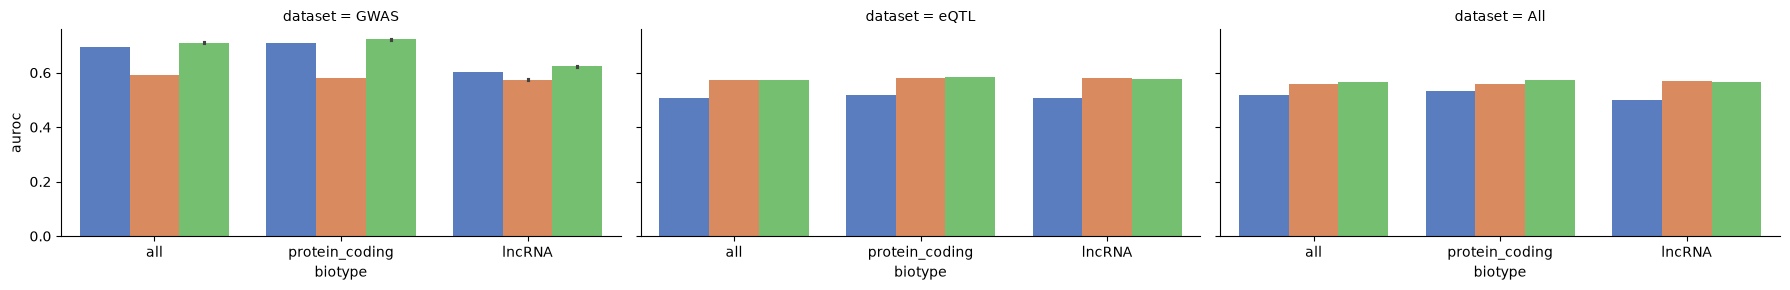

In [ ]:
fg = sns.FacetGrid(data=all_results, col="dataset", aspect=2)
fg.map_dataframe(
    sns.barplot,
    x="biotype",
    y="auroc",
    hue="features",
    palette="muted",
    dodge=True,
)

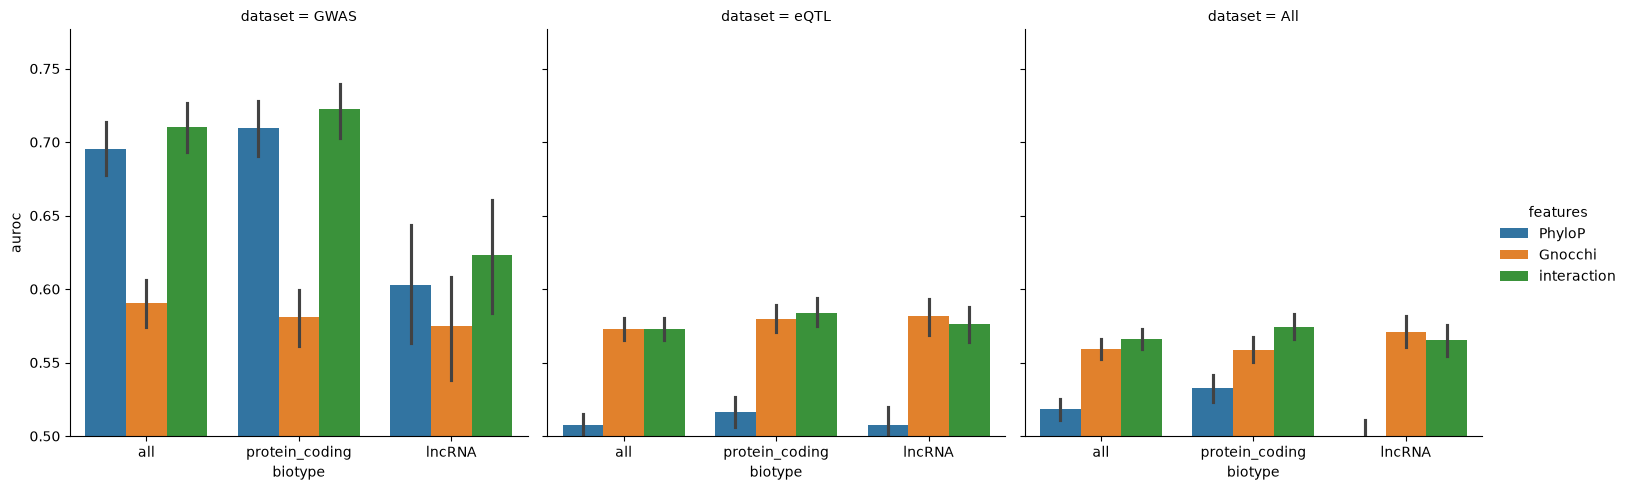

In [ ]:
sns.catplot(
    data=all_results,
    x="biotype",
    y="auroc",
    hue="features",
    col="dataset",
    kind="bar",
    errorbar=("pi", 95),
)
_ = plt.ylim(0.5)
plt.show()

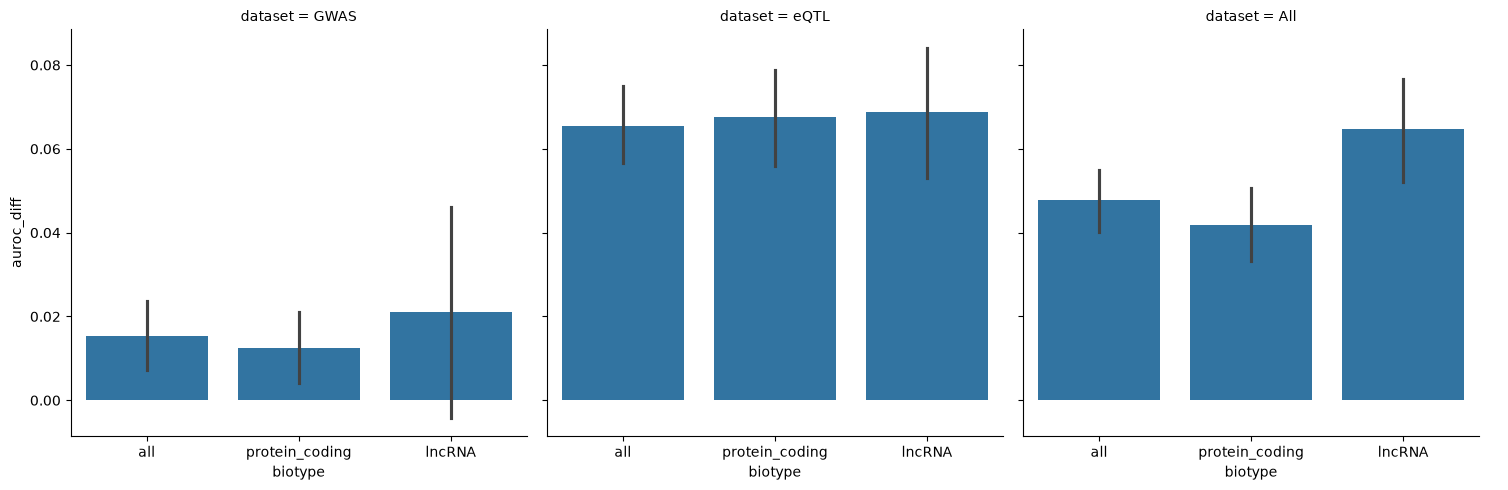

In [ ]:
sns.catplot(
    data=auroc_diffs,
    x="biotype",
    y="auroc_diff",
    col="dataset",
    kind="bar",
    errorbar=("pi", 95),
)

In [ ]:
(
    df.with_columns(
        gwas_hit=pl.when(
            pl.any_horizontal(pl.col("ukbb_label", "multisusie_label") == "high_pip")
        )
        .then(True)
        .otherwise(False),
        eqtl_hit=pl.when(pl.col("eqtl_label") == "high_pip")
        .then(True)
        .otherwise(False),
    )
    .filter(pl.col("gwas_hit") | pl.col("eqtl_hit"))
    .with_columns(
        gwas_only=pl.col("gwas_hit") & ~pl.col("eqtl_hit"),
        eqtl_only=~pl.col("gwas_hit") & pl.col("eqtl_hit"),
        both=pl.col("gwas_hit") & pl.col("eqtl_hit"),
    )
    .select("gwas_only", "eqtl_only", "both")
    .sum()
)


gwas_only,eqtl_only,both
u32,u32,u32
1569,10943,165


In [ ]:
df.head()

variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64
"""chr1:834583:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",834582,834583,204,null,null,null,0.1158,0.3403,0.004209,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.612,null,1.273,null,"""low""",0.936291
"""chr1:835506:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",835505,835506,113,null,null,null,0.1093,0.3085,0.004478,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-2.742,null,2.12,null,"""low""",0.96138
"""chr1:841852:C:T""","""ENSG00000228794""","""chr1""","""C""","""T""","""ENST00000415295""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""SAS""",841851,841852,726,null,null,0.0843,0.06921,0.1493,0.003612,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.459,null,0.094,null,"""low""",1.159831
"""chr1:856473:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""gnomADe_FIN""",856472,856473,2884,null,null,0.07955,0.07915,0.1923,0.002221,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.166,1.535938,0.105,null,"""low""",1.101549
"""chr1:858952:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""EAS""",858951,858952,5363,null,null,0.02083,0.09489,0.1607,0.002458,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-1.531,null,0.916,null,"""low""",1.02278


## ESM-C scores

In [ ]:
esmc_scores = (
    pl.read_csv(
        "/orcd/data/manoli/001/rcalef/projects/vep_comparisons/scoring/collated_variants.esmc_300m.tsv.gz",
        separator="\t",
    )
    # Original scores are log(ref) - log(alt), so negate
    # so we have "pathogenicity" scores instead of
    # "tolerability" scores.
    .with_columns(score=-pl.col("score"))
)
print(esmc_scores.shape)
esmc_scores.head()

In [ ]:
esmc_scores.get_column("score").is_not_null().value_counts()

In [ ]:
merged = df.join(esmc_scores, on=["variant", "gene"], how="inner", validate="1:1")
print(f"{len(df)} -> {len(merged)}")

In [ ]:
merged.head()

In [ ]:
clinvar_check = (
    merged.filter(
        pl.col("clinvar_label").is_not_null(),
        pl.col("biotype") == "protein_coding",
    )
    .with_columns(
        label=pl.when(
            pl.col("clinvar_label").is_in(
                ["Pathogenic", "Likely_pathogenic"],
            )
        )
        .then(pl.lit("pos"))
        .otherwise(pl.lit("neg")),
    )
    .select("score", "label")
)
print(clinvar_check.shape)
clinvar_check.head()

In [ ]:
roc_auc_score(
    y_true=(clinvar_check.get_column("label") == "pos").cast(pl.UInt8).to_numpy(),
    y_score=(clinvar_check.get_column("score")).to_numpy(),
)

In [ ]:
datasets = ["ukbb", "multisusie", "eqtl", "clinvar"]

for ds in datasets:
    print(ds)
    print(merged.get_column(f"{ds}_label").value_counts())

In [ ]:
def score_comparison(
    data: pl.DataFrame,
    all_non_null: bool = True,
    refilter_pip: bool = False,
    high_pip: float = 0.5,
    low_pip: float = 0.1,
    biotypes: list[str] = ["all", "lncRNA", "protein_coding"],
):
    ds_labels = {
        "ukbb": ["high_pip"],
        "multisusie": ["high_pip"],
        "eqtl": ["high_pip"],
        "clinvar": ["Pathogenic", "Likely_pathogenic"],
    }
    label_cols = [f"{ds}_label" for ds in ds_labels]

    if all_non_null:
        data = data.filter(pl.all_horizontal(pl.col(label_cols).is_not_null()))

    by_category = []
    for category in biotypes:
        if category == "all":
            by_category.append(data.with_columns(biotype=pl.lit("all")))
        else:
            by_category.append(
                data.filter(pl.col("biotype") == category),
            )
    by_category = pl.concat(by_category)

    # if refilter_pip:
    #     assert high_pip >= 0.5
    #     assert low_pip <= 0.1
    #     by_category = (
    #         by_category
    #         .with_columns(
    #             label=(
    #                 pl.when(pl.col("pip") >= high_pip)
    #                 .then(pl.lit("high_pip"))
    #                 .otherwise(
    #                     pl.when(pl.col("pip") <= low_pip)
    #                     .then(pl.lit("low_pip"))
    #                     .otherwise(None),
    #                 )
    #             )
    #         )
    #         .filter(pl.col("label").is_not_null())
    #     )

    long = []
    for ds, pos_labels in ds_labels.items():
        long.append(
            by_category.filter(
                pl.col(f"{ds}_label").is_not_null(),
            )
            .with_columns(
                label=pl.when(pl.col(f"{ds}_label").is_in(pos_labels))
                .then(pl.lit("pos"))
                .otherwise(pl.lit("neg")),
                dataset=pl.lit(ds),
            )
            .select("score", "biotype", "label", "dataset")
        )
    long = pl.concat(long, how="vertical")

    all_aucs = {}
    for biotype in biotypes:
        for dataset in ds_labels:
            want_rows = long.filter(
                pl.col("score").is_not_null(),
                pl.col("biotype") == biotype,
                pl.col("dataset") == dataset,
            )
            if len(want_rows) == 0:
                print(f"{dataset} - no data")
                continue

            auc = roc_auc_score(
                y_true=(want_rows.get_column("label") == "pos")
                .cast(pl.UInt8)
                .to_numpy(),
                y_score=(want_rows.get_column("score")).to_numpy(),
            )
            num_pos = (want_rows.get_column("label") == "pos").sum()
            num_neg = (want_rows.get_column("label") != "pos").sum()

            print(f"{dataset}: {biotype} ({num_pos} / {num_neg}) -> AUC={auc:0.3f}")
            all_aucs[(dataset, biotype)] = auc

    fg = sns.FacetGrid(
        long,
        col="dataset",
        row="biotype",
        sharey=False,
    )
    fg.map_dataframe(sns.boxplot, x="label", y="score")

    fg.tight_layout()

    for (biotype, dataset), ax in fg.axes_dict.items():
        auc = all_aucs[(dataset, biotype)]
        ax.set_title(f"dataset={dataset}\nbiotype={biotype}\nAUC={auc:0.3f}")

    return fg

In [ ]:
score_comparison(merged, all_non_null=False, biotypes=["protein_coding"])